In [1]:
import pandas as pd
import numpy as np
# Cargar dataset limpio
CLEAN_PATH = r"C:\Users\santi\Documents\pyrolisis\Data\pyrolysis_clean.csv"
df = pd.read_csv(CLEAN_PATH)
print("Dataset cargado correctamente")
print("Dimensión del dataset:", df.shape)

#imprimir primeras filas para verificar carga
print(df.head())


Dataset cargado correctamente
Dimensión del dataset: (512, 18)
   Index            Biomass species      M  Ash      VM     FC      C     H  \
0      1  Jerusalem artichoke stick  15.76  3.34  67.40  13.50  45.36  6.11   
1      2  Jerusalem artichoke stick  15.76  3.34  67.40  13.50  45.36  6.11   
2      3  Jerusalem artichoke stick  15.76  3.34  67.40  13.50  45.36  6.11   
3      4  Jerusalem artichoke stick  15.76  3.34  67.40  13.50  45.36  6.11   
4      5                       reed   5.89  8.47  72.12  13.52  42.78  5.17   

       O     N   PS   FT    HR     FR  Solid phase  Liquid phase  Gas phase  \
0  47.26  0.75  0.5  550  10.0  100.0        35.00         44.90      20.10   
1  47.26  0.75  0.5  650  10.0  100.0        31.75         41.25      27.00   
2  47.26  0.75  0.5  750  10.0  100.0        30.20         40.60      29.20   
3  47.26  0.75  0.5  850  10.0  100.0        28.60         36.36      35.04   
4  50.51  1.33  0.5  550  10.0  100.0        32.85         54.38   

Diagrama de Van Krevelen
 medida que una biomasa se "carboniza" (pierde H y O relativo al C), se mueve hacia el origen del gráfico. El carbón está cerca del origen, la biomasa fresca está arriba a la derecha, el petróleo está en una posición intermedia
 Una biomasa con O/C alto tiene muchos grupos oxigenados que durante la pirólisis se van como CO, CO₂ y H₂O, favoreciendo gas y un bio-oil muy polar y oxigenado.
Una biomasa con H/C alto tiene más potencial para producir bio-oil energético y compuestos aromáticos.

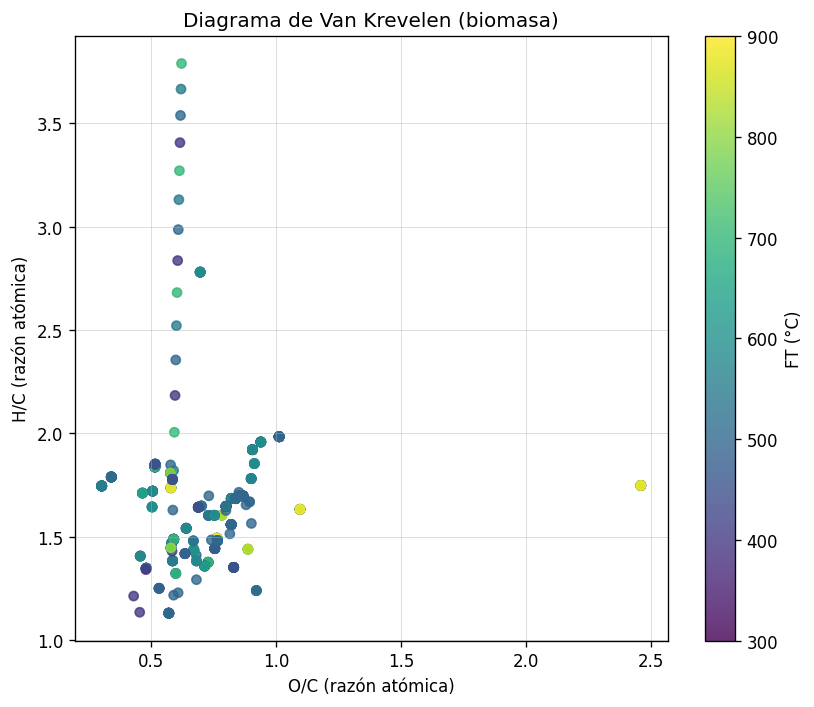

In [2]:
import matplotlib.pyplot as plt

# Pesos atómicos (g/mol)
AW_C = 12.011
AW_H = 1.008
AW_O = 15.999

# Conversión % masa -> moles relativos -> ratios atómicos
moles_C = df["C"] / AW_C
df["H_C"] = (df["H"] / AW_H) / moles_C
df["O_C"] = (df["O"] / AW_O) / moles_C

# Scatter básico Van Krevelen
fig, ax = plt.subplots(figsize=(7, 6), dpi=120)

sc = ax.scatter(
    df["O_C"], df["H_C"],
    c=df["FT"],               # coloreo por temperatura final (FT)
    s=30, alpha=0.8
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("FT (°C)")

ax.set_xlabel("O/C (razón atómica)")
ax.set_ylabel("H/C (razón atómica)")
ax.set_title("Diagrama de Van Krevelen (biomasa)")

# Opcional: invertir ejes si querés el look clásico de algunos papers (no es obligatorio)
# ax.invert_xaxis()

ax.grid(True, linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()

In [3]:
df_vk = df.copy()

# calcular ratios atómicos
AW_C, AW_H, AW_O = 12.011, 1.008, 15.999
moles_C = df_vk["C"] / AW_C
df_vk["H_C"] = (df_vk["H"] / AW_H) / moles_C
df_vk["O_C"] = (df_vk["O"] / AW_O) / moles_C

# quedarte con un punto por especie
df_species = (
    df_vk
    .groupby("Biomass species", as_index=False)[["H_C","O_C"]]
    .mean()
)

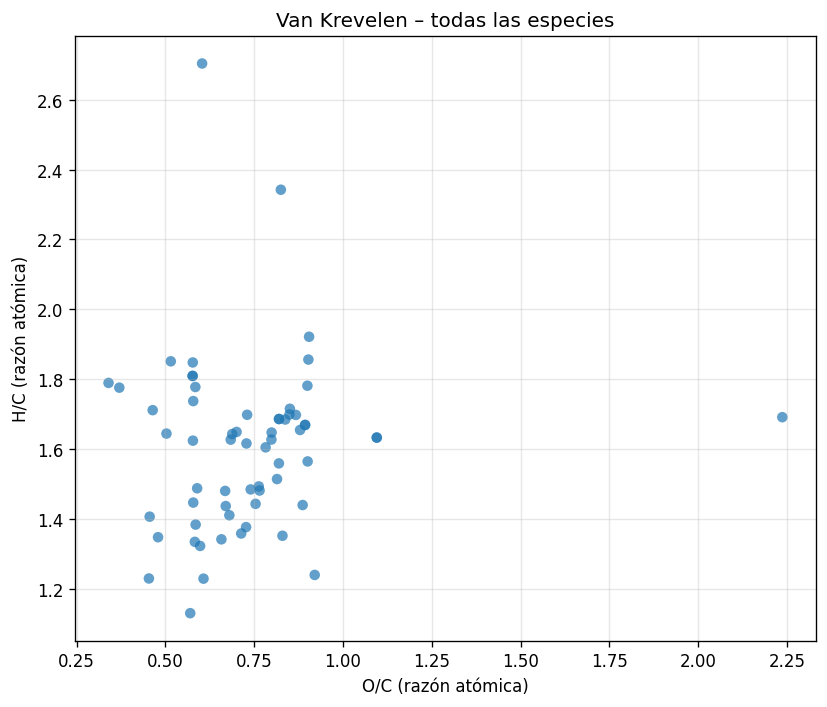

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6), dpi=120)

plt.scatter(
    df_species["O_C"],
    df_species["H_C"],
    s=40,
    alpha=0.7,
    edgecolors="none"
)

plt.xlabel("O/C (razón atómica)")
plt.ylabel("H/C (razón atómica)")
plt.title("Van Krevelen – todas las especies")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

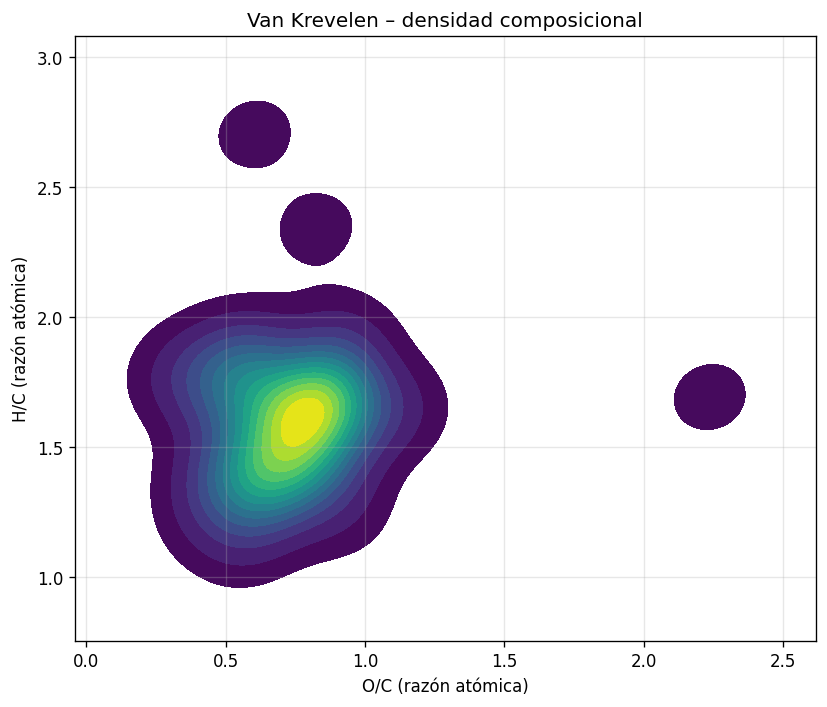

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6), dpi=120)

sns.kdeplot(
    data=df_species,
    x="O_C",
    y="H_C",
    fill=True,
    cmap="viridis",
    levels=15,
    thresh=0.05
)

plt.xlabel("O/C (razón atómica)")
plt.ylabel("H/C (razón atómica)")
plt.title("Van Krevelen – densidad composicional")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
df["Biomass species clean"] = (
    df["Biomass species"]
    .str.lower()
    .str.strip()
)

In [7]:
from collections import Counter

# separar por espacios
all_words = " ".join(df["Biomass species clean"]).split()

word_counts = Counter(all_words)

# ver las 30 más frecuentes
pd.DataFrame(word_counts.most_common(30), columns=["word","count"])

,word,count
0,seed,80
1,rapeseed,37
2,sunflower,37
3,sugar,36
4,stalk,31
5,lampranthus,31
6,spectabilis,31
7,bagasse,30
8,cane,23
9,safflower,23


In [8]:
df["Biomass species clean"].nunique()

59

In [9]:
df[df["Biomass species clean"].str.contains("seed")].shape

(143, 21)

In [10]:
df[df["Biomass species clean"].str.contains("wood")].shape

(16, 21)

In [11]:
def classify_simple(name):
    if "seed" in name:
        return "oil_seed"
    elif "wood" in name:
        return "woody"
    else:
        return "other"

df["group_simple"] = df["Biomass species clean"].apply(classify_simple)

In [12]:
df["group_simple"].value_counts()

group_simple
other       353
oil_seed    143
woody        16
Name: count, dtype: int64

In [13]:
df.groupby("group_simple")[["H_C","O_C"]].mean()

,H_C,O_C
group_simple,,
oil_seed,1.617479,0.526424
other,1.673215,0.774571
woody,1.840842,0.530471


In [14]:
features = ["C","H","O","N","Ash ","VM","FC"]

X = df[features].copy()

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df["PC1"] = X_pca[:,0]
df["PC2"] = X_pca[:,1]

In [17]:
pca.explained_variance_ratio_

array([0.3838577 , 0.21022786])

In [18]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=["PC1","PC2"]
)

loadings

,PC1,PC2
C,0.569989,0.056256
H,0.404618,0.446913
O,-0.515582,0.155665
N,0.264538,0.461594
Ash,-0.214088,0.590934
VM,0.352691,-0.289649
FC,-0.073259,0.355955


PC1 ≈ eje químico redox (C–H vs C–O)
PC2 ≈ eje “mineral / nitrogenado / fracción fija

El análisis exploratorio mostró que las variables composicionales (C, H, O, N, Ash, VM, FC) presentan correlaciones estructurales coherentes con la química de biomasa, destacándose la relación inversa entre carbono (C) y oxígeno (O), consistente con un eje de reducción–oxidación.

El diagrama de Van Krevelen confirmó que las especies se distribuyen a lo largo de un gradiente composicional más que en categorías discretas basadas en nombre.

La clasificación simple por palabras clave (ej. “seed”, “wood”) no explicó adecuadamente las diferencias estructurales esperadas, lo que sugirió que la variabilidad real es composicional y no taxonómica.

El análisis de componentes principales (PCA) permitió condensar la variabilidad química en ejes ortogonales interpretables.

El primer componente (PC1, 38%) representa un eje redox asociado a mayor proporción de enlaces C–H frente a C–O.

El segundo componente (PC2, 21%) captura variación relacionada con contenido mineral, nitrógeno y fracción fija.

En conjunto, los dos primeros componentes explican ~59% de la variabilidad composicional total.

A continuación se graficará PC1 vs PC2 para visualizar si emergen agrupamientos naturales basados en química intrínseca, en lugar de categorías nominales.

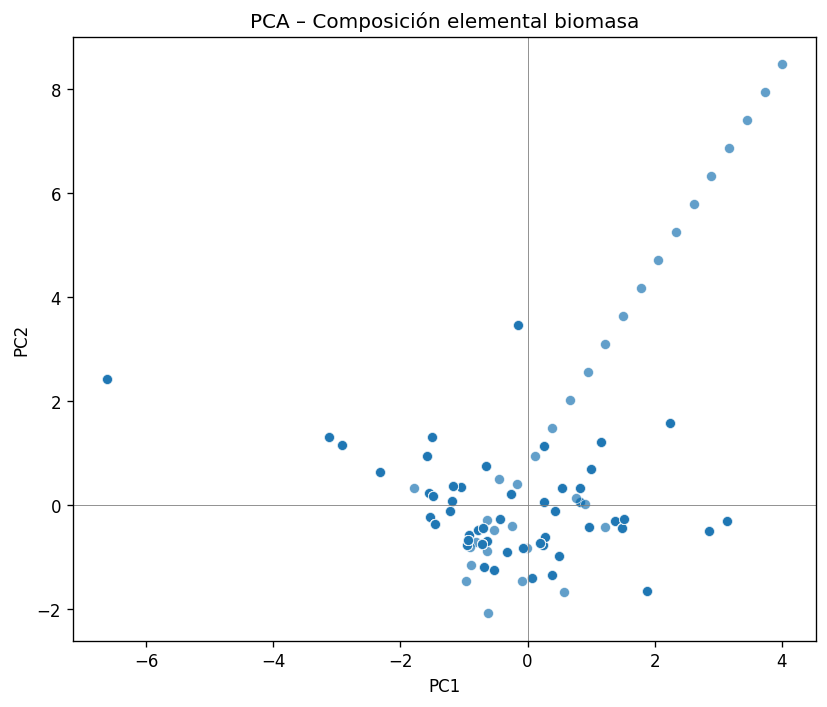

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,6), dpi=120)

sns.scatterplot(
    data=df,
    x="PC1",
    y="PC2",
    alpha=0.7
)

plt.axhline(0, color="grey", linewidth=0.5)
plt.axvline(0, color="grey", linewidth=0.5)

plt.title("PCA – Composición elemental biomasa")
plt.tight_layout()
plt.show()

Clasificar por nombre probablemente sea artificial.
Clasificar por química (usando PC1 y PC2) tiene mucho más sentido.

In [20]:
df.loc[df["PC2"] > 3, "Biomass species clean"].value_counts()

Biomass species clean
tobacco residues                 11
southern bimorphic microalgae     4
Name: count, dtype: int64

Centro → biomasa lignocelulósica típica
Extremo PC2 alto → biomasa rica en N/mineral
Extremo PC1 alto → biomasa más reducida (probablemente más lipídica)

In [21]:
df[["PC1","PC2","Solid phase","Liquid phase","Gas phase"]].corr()

,PC1,PC2,Solid phase,Liquid phase,Gas phase
PC1,1.000000e+00,-4.636660e-16,-0.494788,0.451973,-0.122808
PC2,-4.636660e-16,1.000000e+00,0.226422,-0.147934,-0.039169
Solid phase,-4.947881e-01,2.264216e-01,1.000000,-0.565936,-0.243319
Liquid phase,4.519735e-01,-1.479337e-01,-0.565936,1.000000,-0.639387
Gas phase,-1.228083e-01,-3.916858e-02,-0.243319,-0.639387,1.000000


El rendimiento sólido disminuye con el aumento del carácter reducido de la biomasa (PC1), mientras que aumenta con el contenido mineral/nitrogenado (PC2), evidenciando la influencia simultánea de la estructura orgánica y la fracción inorgánica en la formación de biochar.

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X_model = df[["PC1","PC2"]]
y_model = df["Solid phase"]

model = LinearRegression()
model.fit(X_model, y_model)

y_pred = model.predict(X_model)

r2 = r2_score(y_model, y_pred)

model.coef_, model.intercept_, r2

(array([-2.68211969,  1.65850515]),
 np.float64(30.17060546875),
 0.2960819864134707)

Interpretación técnica:

Coeficiente de PC1 = −2.68
Confirmado.
A mayor carácter reducido (más C–H, menos O), menor fracción sólida.
Esto es químicamente consistente: biomasa más hidrogenada tiende a formar más líquido y menos biochar.

Coeficiente de PC2 = +1.66
También consistente.
Mayor contenido mineral/nitrogenado → mayor residuo sólido.

R² ≈ 0.30
Solo la composición explica ~30% de la variabilidad del rendimiento sólido.

Modelar Liquid ~ PC1 + PC2

Modelar Gas ~ PC1 + PC2

Comparar R² entre fases

Luego agregar FT y ver cuánto aumenta cada uno

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

def fit_linear(target, predictors):
    X = df[predictors]
    y = df[target]
    m = LinearRegression().fit(X, y)
    yhat = m.predict(X)
    return {
        "target": target,
        "predictors": predictors,
        "intercept": float(m.intercept_),
        "coef": dict(zip(predictors, m.coef_)),
        "r2": float(r2_score(y, yhat))
    }

# 1) Solo composición (PC1, PC2)
res_liq = fit_linear("Liquid phase", ["PC1","PC2"])
res_gas = fit_linear("Gas phase", ["PC1","PC2"])

res_liq, res_gas

({'target': 'Liquid phase',
  'predictors': ['PC1', 'PC2'],
  'intercept': 41.0035546875,
  'coef': {'PC1': np.float64(3.09443406230445),
   'PC2': np.float64(-1.3685960642628257)},
  'r2': 0.2261643670841702},
 {'target': 'Gas phase',
  'predictors': ['PC1', 'PC2'],
  'intercept': 28.0355078125,
  'coef': {'PC1': np.float64(-0.7051790056489522),
   'PC2': np.float64(-0.3039130373812849)},
  'r2': 0.01661606490591272})

La composición explica bien la fracción sólida.
Explica moderadamente la fracción líquida.
No explica prácticamente nada del gas.

In [24]:
# 2) Composición + proceso (agregando FT)
res_sol_ft = fit_linear("Solid phase", ["PC1","PC2","FT"])
res_liq_ft = fit_linear("Liquid phase", ["PC1","PC2","FT"])
res_gas_ft = fit_linear("Gas phase", ["PC1","PC2","FT"])

res_sol_ft, res_liq_ft, res_gas_ft

({'target': 'Solid phase',
  'predictors': ['PC1', 'PC2', 'FT'],
  'intercept': 44.29068933047104,
  'coef': {'PC1': np.float64(-2.6277747969617837),
   'PC2': np.float64(1.7766792895831303),
   'FT': np.float64(-0.027544559987812356)},
  'r2': 0.40969001643752123},
 {'target': 'Liquid phase',
  'predictors': ['PC1', 'PC2', 'FT'],
  'intercept': 39.84460406070684,
  'coef': {'PC1': np.float64(3.089973532770878),
   'PC2': np.float64(-1.3782955815301212),
   'FT': np.float64(0.0022608070444367634)},
  'r2': 0.22664415090620982},
 {'target': 'Gas phase',
  'predictors': ['PC1', 'PC2', 'FT'],
  'intercept': 15.69238292629131,
  'coef': {'PC1': np.float64(-0.7526848025471805),
   'PC2': np.float64(-0.40721541299450525),
   'FT': np.float64(0.024078181630841633)},
  'r2': 0.09398373818293804})

FT aumenta fuertemente la capacidad explicativa del modelo de Solid (0.30 → 0.41).
También aumenta la del gas (0.02 → 0.09).
Pero prácticamente no afecta el líquido.

↑ FT → ↓ Solid
↑ FT → ↑ Gas
Liquid ≈ comportamiento no lineal (tiene máximo intermedio, no capturable por modelo lineal simple)

– La fracción sólida está controlada tanto por composición (estructura redox y mineralidad) como por temperatura.
– La fracción gaseosa está dominada principalmente por temperatura.
– La fracción líquida no responde linealmente a FT; su comportamiento probablemente sea curvo (máximo a T intermedia), por eso FT lineal no mejora el modelo.

In [25]:
#Liquid ~ PC1 + PC2 + FT + FT²
df["FT_squared"] = df["FT"] ** 2
res_liq_ft2 = fit_linear("Liquid phase", ["PC1","PC2","FT","FT_squared"])
res_liq_ft2


{'target': 'Liquid phase',
 'predictors': ['PC1', 'PC2', 'FT', 'FT_squared'],
 'intercept': 3.577485712169107,
 'coef': {'PC1': np.float64(2.854241672833137),
  'PC2': np.float64(-1.1313996777774251),
  'FT': np.float64(0.13813681143013817),
  'FT_squared': np.float64(-0.00012156187729477006)},
 'r2': 0.27050817359371937}

FT → +0.138
FT² → −0.0001216

Eso es una parábola cóncava hacia abajo. Predice la cinética de pirólisis para bio-oil:

A bajas temperaturas → poca despolimerización → bajo líquido.
A temperaturas intermedias → máximo de bio-oil.
A temperaturas altas → cracking secundario → más gas, menos líquido.

In [26]:
a = res_liq_ft2["coef"]["FT_squared"]
b = res_liq_ft2["coef"]["FT"]

FT_star = -b / (2*a)
FT_star

np.float64(568.1748855160253)

In [27]:
print(f"Temperatura de máximo rendimiento líquido ≈ {FT_star:.1f} °C")

Temperatura de máximo rendimiento líquido ≈ 568.2 °C


Relación no lineal entre temperatura y fase líquida

El modelo ajustado fue:

Liquid = a·FT² + b·FT + c + β1·PC1 + β2·PC2

donde los coeficientes térmicos estimados fueron:

a = -0.00012156
b = 0.13814

Como a < 0, la relación es parabólica cóncava hacia abajo, lo que implica la existencia de un máximo térmico.

El máximo de una función cuadrática se obtiene en:

FT* = - b / (2a)

Sustituyendo los valores estimados:

FT* = -0.13814 / (2 × -0.00012156)

FT* ≈ 568 °C

Este valor se encuentra dentro del rango típicamente reportado para máximos de producción de bio-oil en pirólisis rápida (≈ 450–600 °C), lo que respalda la coherencia fisicoquímica del modelo y la consistencia estructural del dataset.

Solid phase
– Disminuye con carácter reducido (PC1)
– Aumenta con mineralidad (PC2)
– Disminuye linealmente con FT

Liquid phase
– Aumenta con carácter reducido
– Disminuye con mineralidad
– Presenta máximo térmico ~570 °C

Gas phase
– Poco dependiente de composición
– Aumenta con FT

Eso es coherente con mecanismos conocidos:

Despolimerización primaria → líquidos
Aromatización/condensación → sólidos
Cracking secundario → gas

Y lo más importante:

La composición explica más del comportamiento sólido que del gaseoso.
La temperatura domina el gas.
El líquido depende de ambos y además de no linealidad térmica.

Target seleccionado: Liquid phase
Se seleccionó Liquid phase como target principal por dos razones:
desde el proceso, es la fracción de mayor valor industrial (bio-oil);
desde los datos, es la más compleja de predecir al depender 
simultáneamente de composición, mineralidad y temperatura 
con relación no lineal, a diferencia de Solid y Gas que responden 
más directamente a variables individuales.

Ya sabemos tres cosas clave sobre el líquido:

Aumenta con carácter reducido (PC1) → más enlaces C–H

Disminuye con mineralidad / N (PC2)

Tiene máximo térmico → relación cuadrática con FT

Set de features final:
H/C, O/C, N, Ash, VM, FC, M, FT, FT², HR, PS, FR_imputado, FR_disponible
13 features. Target: Liquid phase

In [28]:
# Features derivadas
df['H_C'] = (df['H'] / 1.008) / (df['C'] / 12.011)
df['O_C'] = (df['O'] / 15.999) / (df['C'] / 12.011)
df['FT_squared'] = df['FT'] ** 2

# Eliminar columnas auxiliares que no van al modelo
df = df.drop(columns=['PC1', 'PC2', 'group_simple', 'Biomass species clean'])

In [29]:
FEAT_PATH = r"C:\Users\santi\Documents\pyrolisis\Data\pyrolysis_features.csv"
df.to_csv(FEAT_PATH, index=False)
print("Exportado:", df.shape)

Exportado: (512, 21)
